<a href="https://colab.research.google.com/github/BartusSoma/football-market-value-analysis/blob/main/Football_Market_Value_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [4]:
import numpy as np

# 1 Adatbázisok beolvasása
players = pd.read_csv('players.csv')
valuations = pd.read_csv('player_valuations.csv')
appearances = pd.read_csv('appearances.csv')
clubs = pd.read_csv('clubs.csv')

In [6]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [7]:
#2 ellenőrzés: méretek kiíratása
print("\n--- Beolvasott táblák (sorok, oszlopok) ---")
print(f"Játékosok: {players.shape}")
print(f"Értékelések: {valuations.shape}")
print(f"Pályára lépések: {appearances.shape}")
print(f"Klubok: {clubs.shape}")


--- Beolvasott táblák (sorok, oszlopok) ---
Játékosok: (47701, 26)
Értékelések: (507815, 6)
Pályára lépések: (1885688, 13)
Klubok: (796, 17)


In [8]:
import numpy as np

# Szűrésekl és tisztítás

#Bajnokságok szűrése (Top 5 liga, Angol, Spanyol, Olasz, Német, Francia)
top_5_leagues = ['GB1', 'ES1', "IT1", "L1", "FR1"]
top_clubs = clubs[clubs['domestic_competition_id'].isin(top_5_leagues)][['club_id', "domestic_competition_id"]]

In [9]:
print(clubs.columns.tolist())

['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']


In [10]:
# szűrések és tisztítás

#Bajnokságok szűrése (Top 5 liga: Angol, Spanyol, Olasz, Német, Francia)
top5_leagues = ['GB1', "ES1", "IT1", 'L1', "FR1"]
top_clubs = clubs[clubs['domestic_competition_id'].isin(top5_leagues)][["club_id", "domestic_competition_id"]]

In [11]:
#Játékosok szűrése a Top 5 ligára
top_players = players[players["current_club_id"].isin(top_clubs["club_id"])].copy()

In [12]:
#Kapusok kiszűrése
top_players = top_players[top_players["position"] != "Goalkeeper"]

In [13]:
#Életkor kiszámítása (2026 - születési év, mivel befejeződött a 25/26-os szezon)
top_players["date_of_birth"] = pd.to_datetime(top_players['date_of_birth'], errors="coerce")
top_players['Age'] = 2026 - top_players['date_of_birth'].dt.year

In [14]:
#Szerződésből hátralévő idő kiszámítása
top_players['contract_expiration_date'] = pd.to_datetime(top_players["contract_expiration_date"], errors="coerce")
top_players["Contract_Years_Left"] = top_players['contract_expiration_date'].dt.year - 2026

In [15]:
# 2. teljesítmény (játékidő és kanadai pontok 25/26os szezonban)
# csak a befejezett meccsek 2025 aug 01.-től
apps_2526 = appearances[appearances['date'] >= "2025-08-01"].copy()

#játékosonkénti aggregálás
perf = apps_2526.groupby('player_id').agg( Minutes_Played = ("minutes_played", "sum"),
                                          Goals = ("goals", 'sum'),
                                           Assists = ("assists", "sum")
).reset_index()

In [16]:
# gól + gólpassz
perf["Goal_Contributions"] = perf["Goals"] + perf["Assisst"]

KeyError: 'Assisst'

In [17]:
#gól+gólpassz

In [18]:
perf["Goal_Contributions"] = perf["Goals"] + perf["Assists"]

In [19]:
#3. piaci érték (legfrissebb érték)
valuations["date"] = pd.to_datetime(valuations["date"])
#dátum szertin sorbarendezem, majd minden játékosnál az utolsó adatot tartom meg, mert az a legfrissebb
latest_val = valuations.sort_values("date").groupby("player_id").tail(1).copy()
latest_val = latest_val[["player_id", "market_value_in_eur"]]

In [20]:
from IPython.display import display

In [21]:
#oszlop átnevezés és millió euróba váltás
latest_val = latest_val.rename(columns={"market_value_in_eur": "Market_Value"})
latest_val["Market_Value"] = latest_val["Market_Value"] / 1000000

In [22]:
print(f"--> Piaci értékek (millió euróban) megkeresve {latest_val.shape[0]} játékoshoz.")
display(latest_val.head(3))

--> Piaci értékek (millió euróban) megkeresve 31507 játékoshoz.


,player_id,Market_Value
4565,16733,0.10
15870,73096,0.05
31705,62553,0.20


In [23]:
# 4. táblák egyesítése
#játékosok és klubok
df = pd.merge(top_players, top_clubs, left_on = "current_club_id", right_on = "club_id", how = "inner")
#teljesítmény hozzáadása
df = pd.merge( df, perf, on="player_id", how="inner")
#piaci érték hozzáadása
df = pd.merge(df, latest_val, on="player_id", how="inner")
# a modellünkhöz szükséges oszlopok kiválasztása
columns_to_keep = ["name", "Age", "country_of_citizenship", "domestic_competition_id", "position", "Minutes_Played", "Contract_Years_Left", "Goal_Contributions", "Market_Value"]
df = df[columns_to_keep]

In [24]:
print(f"--> jelenlegi sorok száma: {df.shape[0]}")
display(df.head(3))

--> jelenlegi sorok száma: 2007


,name,Age,country_of_citizenship,domestic_competition_id,position,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value
0,James Milner,40.0,England,GB1,Midfield,946,0.0,2,0.75
1,Jonas Hofmann,34.0,Germany,L1,Midfield,1288,1.0,6,2.00
2,Daley Blind,36.0,Netherlands,ES1,Defender,2610,0.0,0,1.40


In [25]:
#5. hiányzó adatok kezelése
df = df.dropna()
#csak azokat tartjuk meg, akiknek az idei szezon végén még van érvényes szerződése
df = df[df["Contract_Years_Left"] >= 0]

In [26]:
print ('Adatbázis elkészítve a 2025/26-os szezonra!')
print ("Játékosok száma a tisztítás után: {df.shape[0]} fő")
display(df.head())

Adatbázis elkészítve a 2025/26-os szezonra!
Játékosok száma a tisztítás után: {df.shape[0]} fő


,name,Age,country_of_citizenship,domestic_competition_id,position,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value
0,James Milner,40.0,England,GB1,Midfield,946,0.0,2,0.75
1,Jonas Hofmann,34.0,Germany,L1,Midfield,1288,1.0,6,2.00
2,Daley Blind,36.0,Netherlands,ES1,Defender,2610,0.0,0,1.40
3,Raúl Albiol,41.0,Spain,IT1,Defender,570,0.0,1,0.80
4,Santi Cazorla,42.0,Spain,ES1,Midfield,924,0.0,1,0.50


In [27]:
print ('Adatbázis elkészítve a 2025/26-os szezonra!')
print (f"Játékosok száma a tisztítás után: {df.shape[0]} fő")
display(df.head())

Adatbázis elkészítve a 2025/26-os szezonra!
Játékosok száma a tisztítás után: 1965 fő


,name,Age,country_of_citizenship,domestic_competition_id,position,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value
0,James Milner,40.0,England,GB1,Midfield,946,0.0,2,0.75
1,Jonas Hofmann,34.0,Germany,L1,Midfield,1288,1.0,6,2.00
2,Daley Blind,36.0,Netherlands,ES1,Defender,2610,0.0,0,1.40
3,Raúl Albiol,41.0,Spain,IT1,Defender,570,0.0,1,0.80
4,Santi Cazorla,42.0,Spain,ES1,Midfield,924,0.0,1,0.50


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

In [29]:
print( "--- Outlierek szűrése seabornnal")
#Készítünk egy dobozdiagramot a piaci értékek eloszlásáról
plt.figure(figsize(10, 4))
sns.boxplot(x=df['Market_Value'])
plt.title("Piaci értékek eloszlása az outlierek szűrése előtt (Millió EUR)")
plt.show()

--- Outlierek szűrése seabornnal


NameError: name 'figsize' is not defined

--- Outlierek szűrése seabornnal


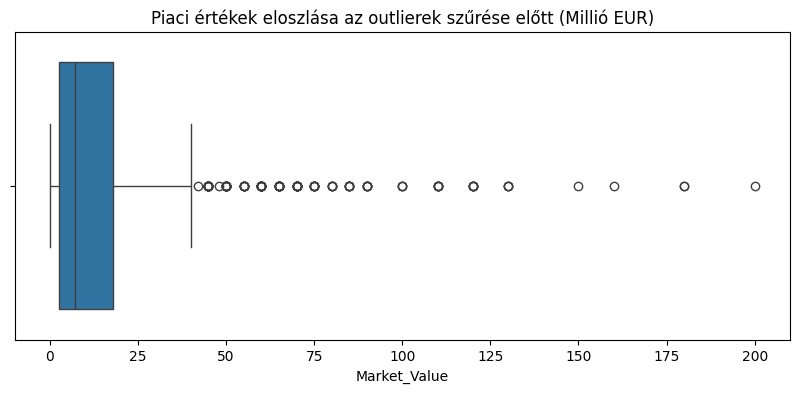

In [30]:
print( "--- Outlierek szűrése seabornnal")
#Készítünk egy dobozdiagramot a piaci értékek eloszlásáról
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Market_Value'])
plt.title("Piaci értékek eloszlása az outlierek szűrése előtt (Millió EUR)")
plt.show()

In [31]:
#Kiszűrjük a legextrémebb 1%-ot, hogy ne torzítsák a modellt
q99 = df['Market_Value'].quantile(0.99)
df = df[df["Market_Value"] <= q99]

print(f" Extrém kiugró értékek (>{q99:.1f}M EUR) eltávolítva.")
print(f"Játékosok száma a szűrés után: {df.shape[0]} fő. \n")

 Extrém kiugró értékek (>100.0M EUR) eltávolítva.
Játékosok száma a szűrés után: 1947 fő. 



In [32]:
print(" --- 2. Dummy változók generálása")
#Nemzetiségek egyszerűsítése (Angol, Spanyol, Francia, Egyéb csoportok)
def categorize_nationality(country):
  if country == "England" : return "English"
  elif country == "Spain" : return "Spanish"
  elif country == "France" : return "French"
  else: return "Other"

df["Nationality_Group"] = df["country_of_citizenship"].apply(categorize_nationality)

 --- 2. Dummy változók generálása


In [33]:
#Bajnokságok dummyzása (Referencia: GB1)
league_dummies = pd.get_dummies(df["domestic_competition_id"], prefix="League", dtype=int)
league_dummies = league_dummies_drop("League_GB1", axis=1)

NameError: name 'league_dummies_drop' is not defined

In [34]:
#Bajnokságok dummyzása (Referencia: GB1)
league_dummies = pd.get_dummies(df["domestic_competition_id"], prefix="League", dtype=int)
league_dummies = league_dummies.drop("League_GB1", axis=1)

In [35]:
#Posztok dummyzása (Referencia: Attacker)
position_dummies = pd.get_dummies(df['position'], prefix="Pos" , dytpe=int)
if "Pos_Attack" in position_dummies.columns:
  position_dummies = position_dummies.drop("Pos_Attack", axis=1)

TypeError: get_dummies() got an unexpected keyword argument 'dytpe'

In [36]:
#Posztok dummyzása (Referencia: Attacker)
position_dummies = pd.get_dummies(df['position'], prefix="Pos" , dtype=int)
if "Pos_Attack" in position_dummies.columns:
  position_dummies = position_dummies.drop("Pos_Attack", axis=1)

In [37]:
#Nemzetiségek dummyzása (Referencia: English)
nat_dummies = pd.get_dummies(df["Nationlity_Group"], prefix="Nat", dtype=int)
nat_dummies = nat_dummies.drop("Nat_English", axis=1)

KeyError: 'Nationlity_Group'

In [38]:
#Nemzetiségek dummyzása (Referencia: English)
nat_dummies = pd.get_dummies(df["Nationality_Group"], prefix="Nat", dtype=int)
nat_dummies = nat_dummies.drop("Nat_English", axis=1)

In [39]:
#táblázat összeállítása dummykkal
df_model = pd.concat([df[['Age', "Minutes_Played", "Contract_Years_Left", "Goal_Contributions", "Market_Value""]],
league_dummies, position_dummies, nat_dummies], axis=1)

SyntaxError: unterminated string literal (detected at line 2) (1228399222.py, line 2)

In [40]:
df_model = pd.concat([df[['Age', 'Minutes_Played', 'Contract_Years_Left', 'Goal_Contributions', 'Market_Value']],
                      league_dummies, position_dummies, nat_dummies], axis=1)

In [41]:
print(" Dummy változók legenerálva.")
display(df_model.head(3))

 Dummy változók legenerálva.


,Age,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value,League_ES1,League_FR1,League_IT1,League_L1,Pos_Defender,Pos_Midfield,Nat_French,Nat_Other,Nat_Spanish
0,40.0,946,0.0,2,0.75,0,0,0,0,0,1,0,0,0
1,34.0,1288,1.0,6,2.00,0,0,0,1,0,1,0,1,0
2,36.0,2610,0.0,0,1.40,1,0,0,0,1,0,0,1,0


In [42]:
#eredményváltozó és magyarázó változók szétválasztása
y= df_model['Market_Value"']
x = df_model.drop('Market_Value", axis=1')

KeyError: 'Market_Value"'

In [43]:
#eredményváltozó és magyarázó változók szétválasztása
y= df_model['Market_Value']
x = df_model.drop('Market_Value', axis=1)

In [44]:
#tengelymetszet hozzáadása

In [45]:
x = sm.add_constant(x)

In [46]:
#a modell illesztése és eredmények kiszámolása
model = sm.OLS(y, x).fit()

In [47]:
print("A modell lefutott. Az eredmények:")
display(model.summary())

A modell lefutott. Az eredmények:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Market_Value   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     99.56
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          4.30e-204
Time:                        09:12:16   Log-Likelihood:                -7680.9
No. Observations:                1947   AIC:                         1.539e+04
Df Residuals:                    1933   BIC:                         1.547e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  15.3706      2.470      6.223      0.000      10.527      20.215
Age                    -0.4228      0.076     -5.557      0.000      -0.572      -0.274
Minutes_Played          0.0029      0.000      8.245      0.000       0.002       0.004
Contract_Years_Left     1.7841      0.225      7.925      0.000       1.343       2.226
Goal_Contributions      0.9883      0.069     14.259      0.000       0.852       1.124
League_ES1             -9.2978      1.065     -8.727      0.000     -11.387      -7.208
League_FR1            -10.8308      0.986    -10.986      0.000     -12.764      -8.897
League_IT1             -8.8729      0.898     -9.883      0.000     -10.634      -7.112
League_L1             -10.2045      0.953    -10.702      0.000     -12.075      -8.335
Pos_Defender            2.6639      0.859      3.102      0.002       0.980       4.348
Pos_Midfield            2.0462      0.801      2.554      0.011       0.475       3.617
Nat_French              3.6150      1.455      2.484      0.013       0.761       6.469
Nat_Other               1.7227      1.159      1.486      0.137      -0.551       3.996
Nat_Spanish            -0.6935      1.531     -0.453      0.651      -3.696       2.309
==============================================================================
Omnibus:                      693.504   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3109.358
Skew:                           1.657   Prob(JB):                         0.00
Kurtosis:                       8.229   Cond. No.                     1.94e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.94e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [48]:
#Mivel mindegyik változó szignifikáns, illetve a nemzetiség dummynál legalább 1 ismérv(Nat_French) szignifikáns, ezért nem kell kivennünk egy változót sem a modellünkből

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from IPython.display import display

In [50]:
print("--- A modell jóságának értékelés globális F-próbával---")
#Kinyerjük a Python modell objektumából a globális F-próba pontos p-értékét
f_pvalue = model.f_pvalue
print(f"A globális F-próba p-értéke: {f_pvalue}")
print("Értékelés: Mivel ez az érték gyakorlatilag 0 (vastagon kisebb, mint a 0.05-ös küszöb),")
print("a modellünk globálisan szignifikáns. Ez azt jelenti, hogy a magyarázó változóink")
print("együttesen valóban képesek magyarázni a piaci értéket, és szignifikánsan jobb")
print("eredményt adnak annál, mintha mindenkinek csak az átlagos piaci értékét tippelnénk meg.\n")

--- A modell jóságának értékelés globális F-próbával---
A globális F-próba p-értéke: 4.3026506844626784e-204
Értékelés: Mivel ez az érték gyakorlatilag 0 (vastagon kisebb, mint a 0.05-ös küszöb),
a modellünk globálisan szignifikáns. Ez azt jelenti, hogy a magyarázó változóink
együttesen valóban képesek magyarázni a piaci értéket, és szignifikánsan jobb
eredményt adnak annál, mintha mindenkinek csak az átlagos piaci értékét tippelnénk meg.



In [51]:
print("--- A multikollinearitás vizsgálata (VIF mutatók) ---")
# Létrehozunk egy üres táblázatot, amiben eltároljuk a változók neveit
vif_data = pd.DataFrame()
vif_data["Változó"] = x.columns

--- A multikollinearitás vizsgálata (VIF mutatók) ---


In [52]:
print("--- A multikollinearitás vizsgálata (VIF mutatók) ---")
# Létrehozunk egy üres táblázatot, amiben eltároljuk a változók neveit
vif_data = pd.DataFrame()
vif_data["Változó"] = x.columns

--- A multikollinearitás vizsgálata (VIF mutatók) ---


In [53]:
# Egy ciklus segítségével kiszámoljuk a VIF értéket az x mátrix minden egyes oszlopára
vif_data["VIF_Érték"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

In [54]:
print("VIF mutatók sikeresen kiszámolva!")
print(" Az 5 feletti érték")
print("veszélyes multikollinearitást (erős együttmozgást) jelez a magyarázó változók között.")

# Csökkenő sorrendben, 2 tizedesjegyre kerekítve kiíratjuk a táblázatot
display(vif_data.sort_values(by="VIF_Érték", ascending=False).round(2))

VIF mutatók sikeresen kiszámolva!
 Az 5 feletti érték
veszélyes multikollinearitást (erős együttmozgást) jelez a magyarázó változók között.


,Változó,VIF_Érték
0,const,75.42
12,Nat_Other,3.63
13,Nat_Spanish,3.40
11,Nat_French,2.52
5,League_ES1,2.26
9,Pos_Defender,2.18
4,Goal_Contributions,2.06
2,Minutes_Played,1.77
10,Pos_Midfield,1.71
6,League_FR1,1.70


In [55]:
print(Korrelációs mátrix és inverzmátrix)

#1. korrelációs mátrix
corr_matrix = df_model.corr()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (458990348.py, line 1)

In [56]:
print("Korrelációs mátrix és inverzmátrix")

#1. korrelációs mátrix
corr_matrix = df_model.corr()

Korrelációs mátrix és inverzmátrix


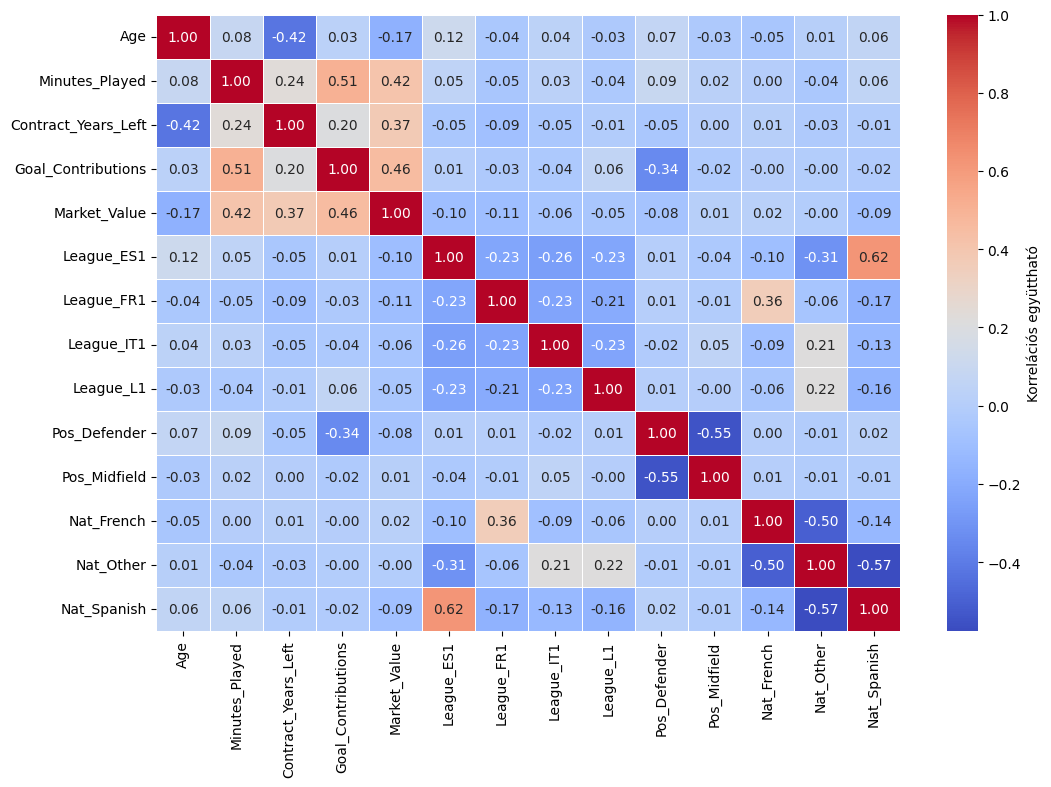

In [57]:
#hőtérkép
plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"label": "Korrelációs együttható"})
plt.show()

In [58]:
#eredményváltozó előre hozása
#1. lekérjük az összes oszlopnevet
cols = df_model.columns.tolist()

In [59]:
#kivesszük az eredményváltozót (piaci érték) a jelenlegi helyéről
cols.remove("Market_Value")
#és betesszük a lista elejére
cols = ["Market_Value"] + cols

In [60]:
# újra felírjuk a mátrixot
df_model = df_model[cols]

#korrelációs mátrix
corr_matrix = df_model.corr()

In [61]:
#ábrázolása
plt.figure(figsize = (14, 10)) #kicsit nagyobbra vettem az olvashatóságért
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"label",: "Korrelációs együttható"})
#cím
plt.title("Változók közötti korrelációs mátrix")
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3009872147.py, line 3)

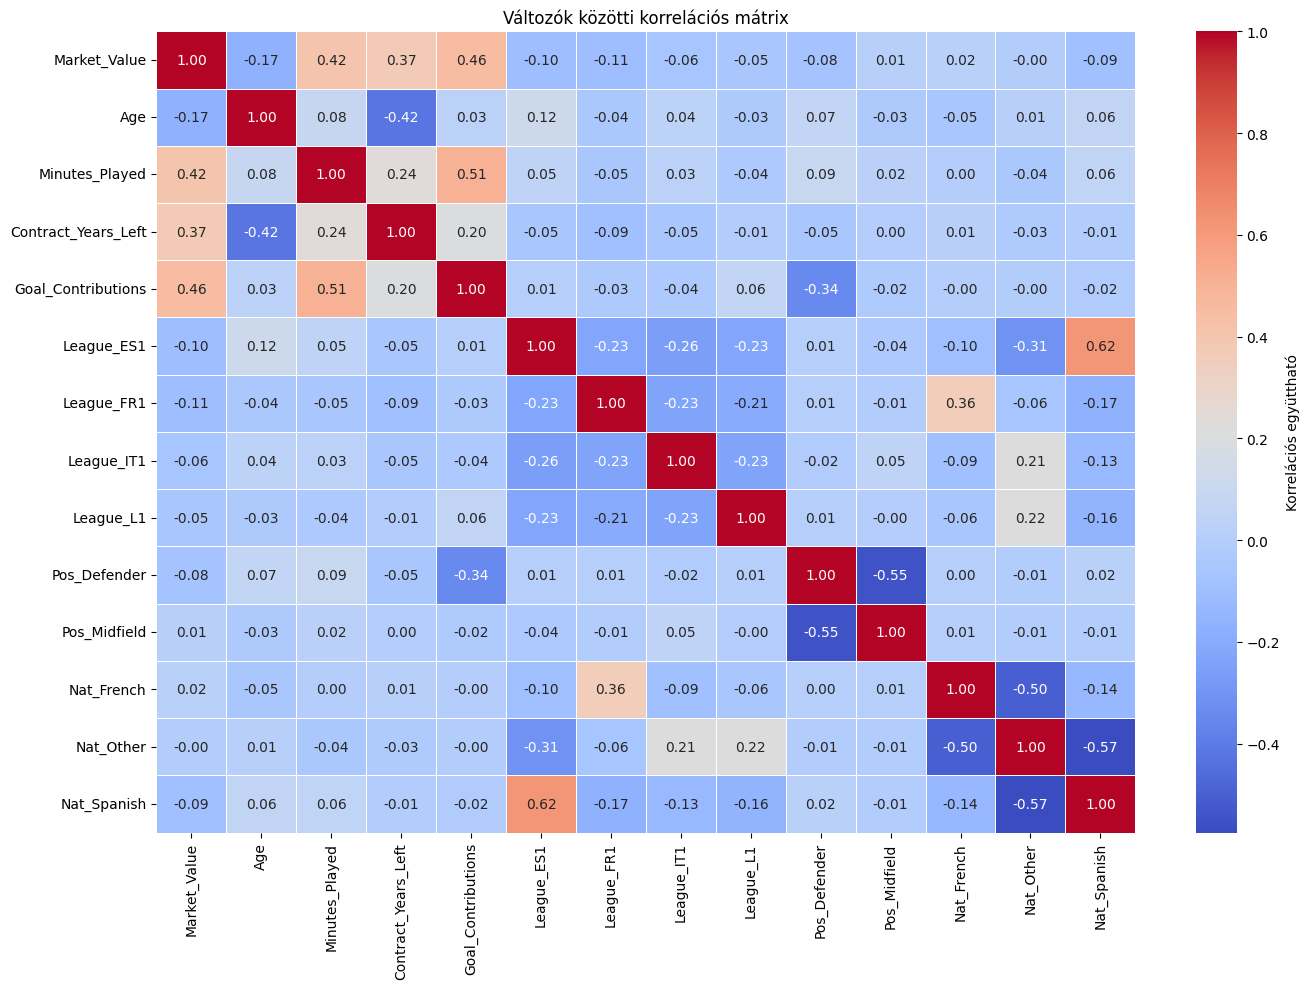

In [62]:
#ábrázolása
plt.figure(figsize = (14, 10)) #kicsit nagyobbra vettem az olvashatóságért
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"label": "Korrelációs együttható"})
#cím
plt.title("Változók közötti korrelációs mátrix")
plt.tight_layout()
plt.show()

In [63]:
#mivel a korrelációs mátrix szimmetrikus, ezért a mátrix felső felére nincs szükségünk
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

#megnöveljük a méretét mert nehezen olvasható
plt.figure(figsize=(18, 14))

#ábrázolás
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidth=0.5,
            annot_kws={"size": 14},
            cbar_kws={"shrink": 0,8, "label": "Korrelációs együttható"})

SyntaxError: ':' expected after dictionary key (925143511.py, line 15)

<Axes: >

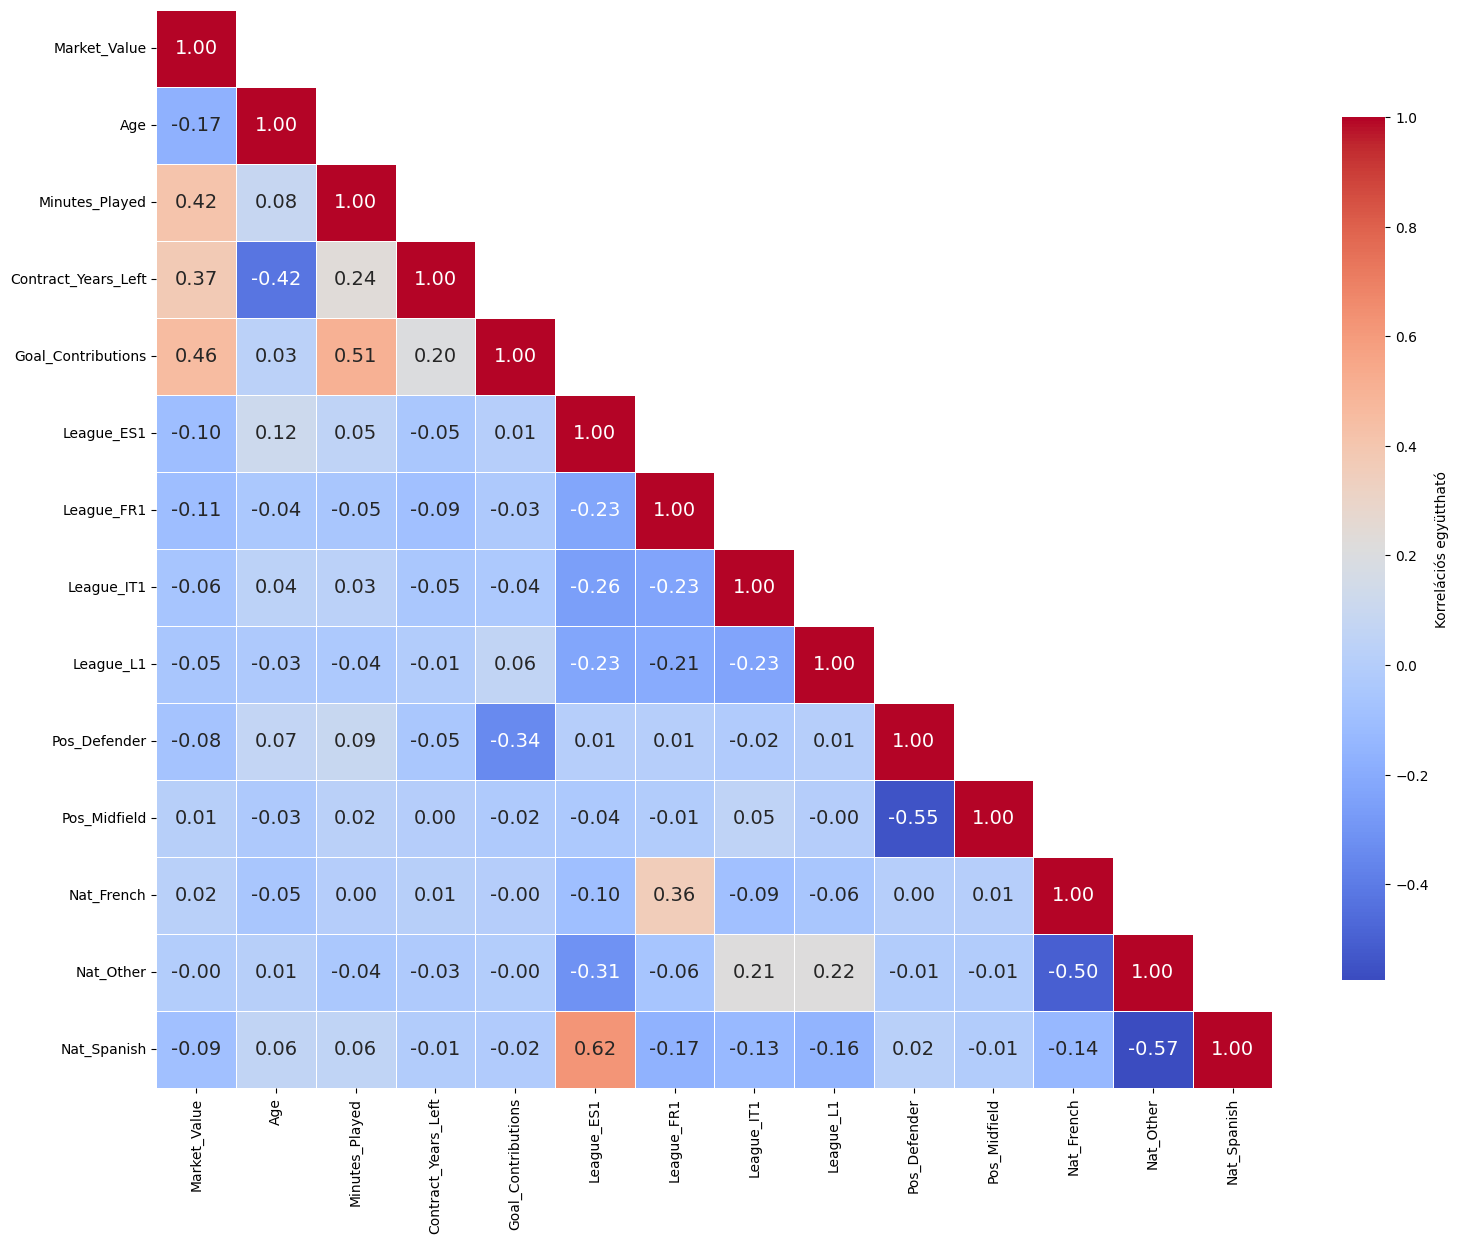

In [64]:
#mivel a korrelációs mátrix szimmetrikus, ezért a mátrix felső felére nincs szükségünk
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

#megnöveljük a méretét mert nehezen olvasható
plt.figure(figsize=(18, 14))

#ábrázolás
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidth=0.5,
            annot_kws={"size": 14},
            cbar_kws={"shrink": 0.8, "label": "Korrelációs együttható"})

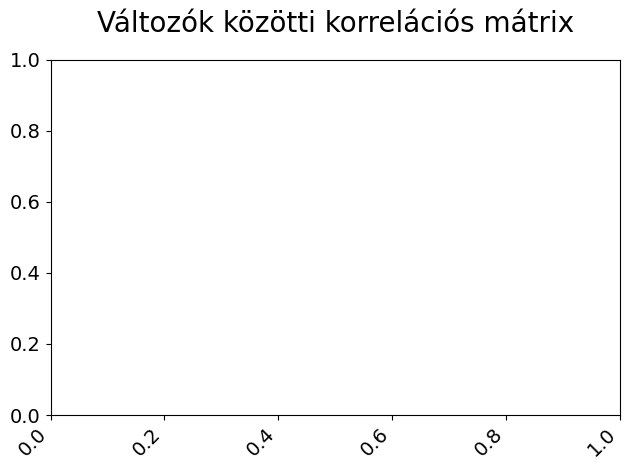

In [65]:
#tengelyfeliratok és cím
plt.title("Változók közötti korrelációs mátrix", fontsize=20, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.show()

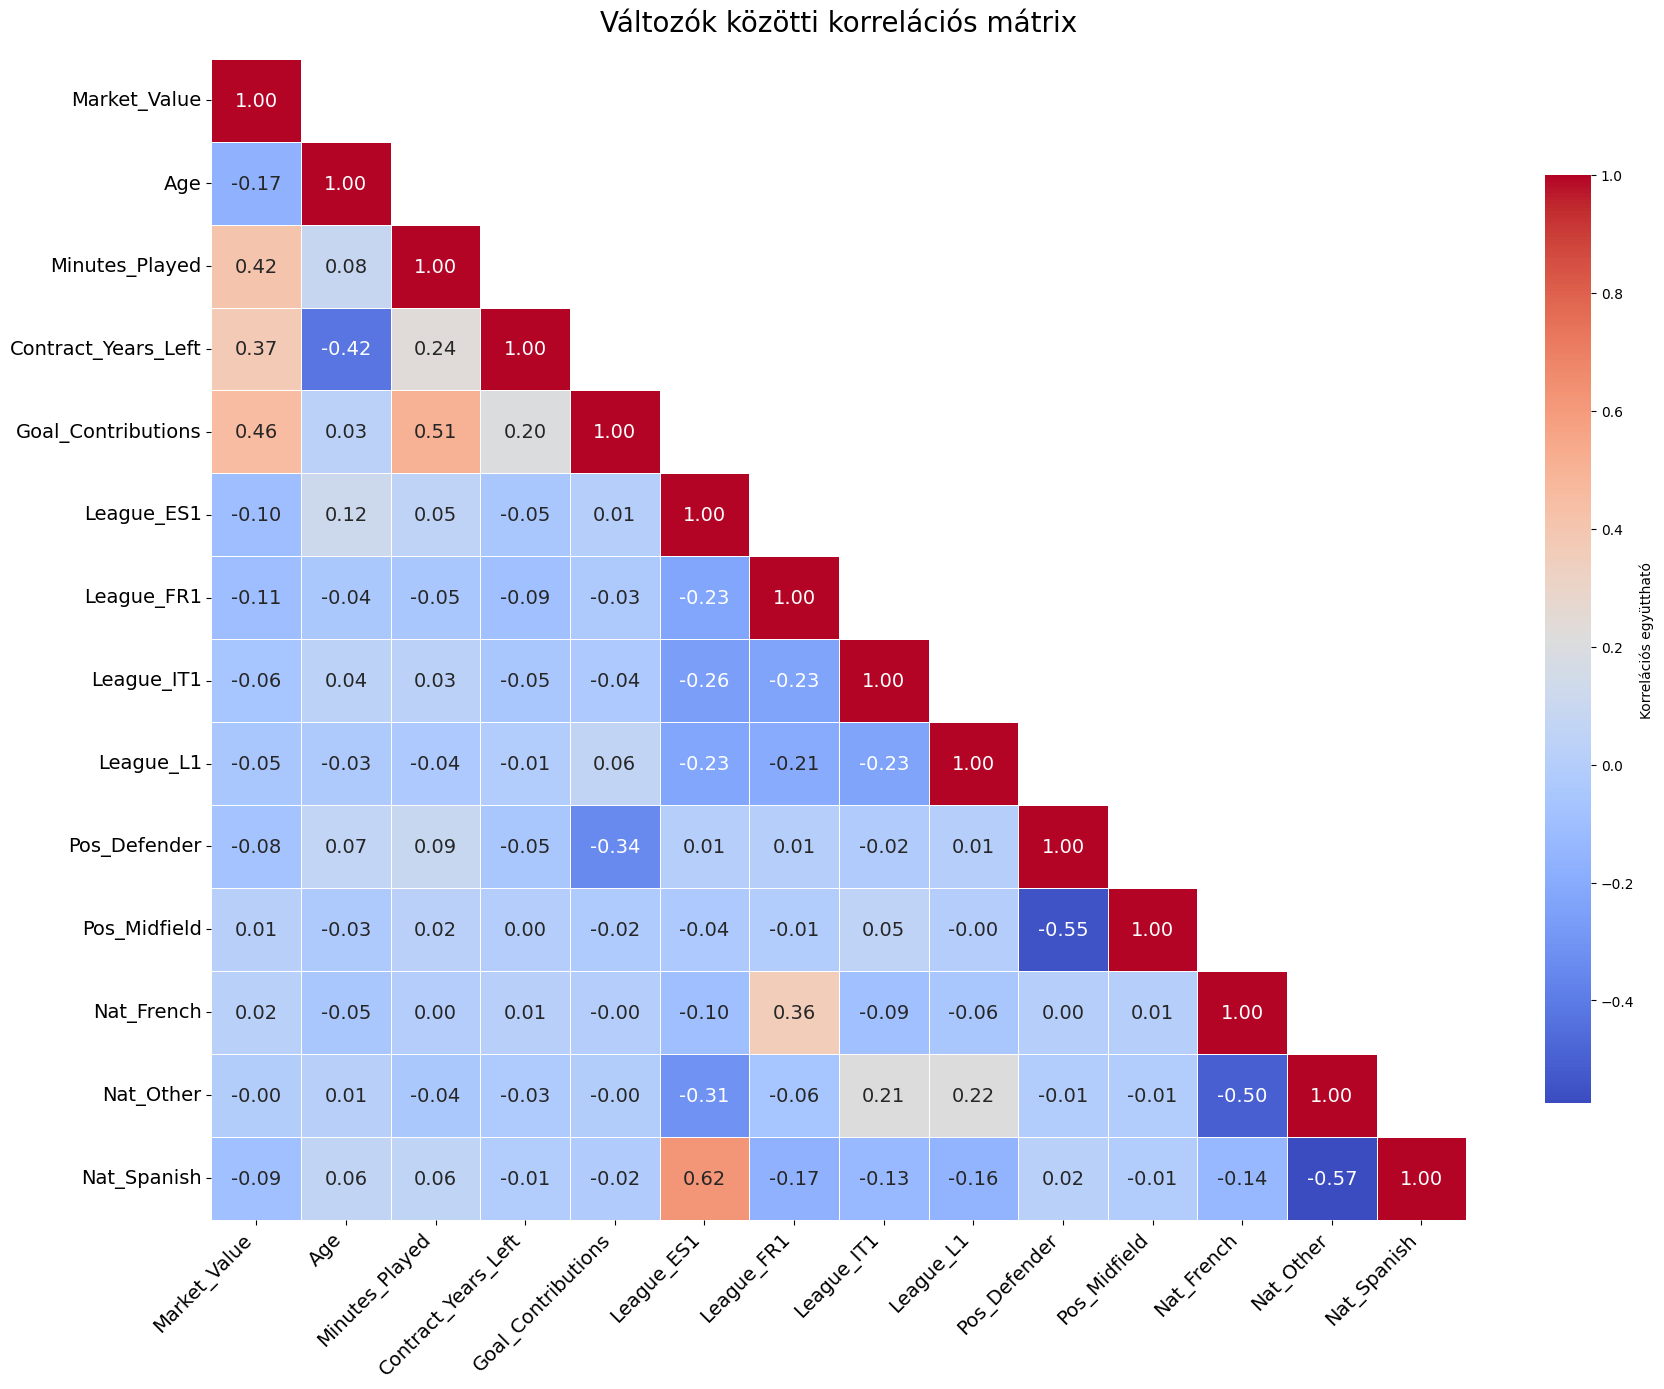

In [66]:
#egybe ábrázolva mindkettő

#mivel a korrelációs mátrix szimmetrikus, ezért a mátrix felső felére nincs szükségünk
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

#megnöveljük a méretét mert nehezen olvasható
plt.figure(figsize=(18, 14))

#ábrázolás
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidth=0.5,
            annot_kws={"size": 14},
            cbar_kws={"shrink": 0.8, "label": "Korrelációs együttható"})
#tengelyfeliratok és cím
plt.title("Változók közötti korrelációs mátrix", fontsize=20, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
print("Inverz mátrix")
# kiveszem az eredményváltozót, mivel a magyarázó változók közötti inverzmátrixot szeretném ábrázolni és vizsgálni
x_for_inv = df_model.drop(columns=["Market_Value"])
if "const" in x_for_inv.columns:
  x_for_inv = x_for_inv.drop(columns=["const"])

  #korrelációs mátrix magyarázó változókra
  corr_x = x_for_inv.corr()

  #inverzmátrix
  inv_corr_matrix = pd.DataFrame(np.linalg.inv(corr_x.values),
                                 index=corr_x.columns,
                                 columns= corr_x.columns)

  print("A mátrix főátlójában pontosan a korábban már kiszámolt")
  print("VIF-mutatók szerepelnek, mivel az eredményváltozót kiszedtük.")
  print("Ez által tudjuk vizsgálni a multikollinearitást")

  display(inv_corr_matrix.round(2))

Inverz mátrix


In [69]:
print("Inverz mátrix")
# kiveszem az eredményváltozót, mivel a magyarázó változók közötti inverzmátrixot szeretném ábrázolni és vizsgálni
x_for_inv = df_model.drop(columns=["Market_Value"])
if "const" in x_for_inv.columns:
  x_for_inv = x_for_inv.drop(columns=["const"])

#korrelációs mátrix magyarázó változókra
corr_x = x_for_inv.corr()

#inverzmátrix
inv_corr_matrix = pd.DataFrame(np.linalg.inv(corr_x.values),
                               index=corr_x.columns,
                               columns= corr_x.columns)

print("A mátrix főátlójában pontosan a korábban már kiszámolt")
print("VIF-mutatók szerepelnek, mivel az eredményváltozót kiszedtük.")
print("Ez által tudjuk vizsgálni a multikollinearitást")

display(inv_corr_matrix.round(2))

Inverz mátrix
A mátrix főátlójában pontosan a korábban már kiszámolt
VIF-mutatók szerepelnek, mivel az eredményváltozót kiszedtük.
Ez által tudjuk vizsgálni a multikollinearitást


,Age,Minutes_Played,Contract_Years_Left,Goal_Contributions,League_ES1,League_FR1,League_IT1,League_L1,Pos_Defender,Pos_Midfield,Nat_French,Nat_Other,Nat_Spanish
Age,1.30,-0.18,0.61,-0.11,-0.11,0.08,-0.01,0.05,-0.09,-0.01,0.00,-0.05,0.00
Minutes_Played,-0.18,1.77,-0.30,-1.14,-0.02,0.03,-0.07,0.11,-0.85,-0.53,-0.07,-0.07,-0.13
Contract_Years_Left,0.61,-0.30,1.40,-0.14,0.16,0.26,0.19,0.17,0.02,0.03,-0.07,-0.06,-0.05
Goal_Contributions,-0.11,-1.14,-0.14,2.06,-0.05,-0.06,0.02,-0.20,1.22,0.73,0.10,0.15,0.18
League_ES1,-0.11,-0.02,0.16,-0.05,2.26,0.76,0.86,0.76,0.03,0.04,-0.51,-0.71,-1.51
League_FR1,0.08,0.03,0.26,-0.06,0.76,1.70,0.78,0.74,-0.03,-0.02,-0.80,-0.64,-0.45
League_IT1,-0.01,-0.07,0.19,0.02,0.86,0.78,1.65,0.79,0.01,-0.04,-0.46,-0.76,-0.56
League_L1,0.05,0.11,0.17,-0.20,0.76,0.74,0.79,1.59,-0.13,-0.09,-0.47,-0.75,-0.50
Pos_Defender,-0.09,-0.85,0.02,1.22,0.03,-0.03,0.01,-0.13,2.18,1.23,0.05,0.10,0.06
Pos_Midfield,-0.01,-0.53,0.03,0.73,0.04,-0.02,-0.04,-0.09,1.23,1.71,0.05,0.11,0.06


In [71]:
print("A modellfeltételek vizsgálata")

print("\n1. Feltétel: A magyarázó változók nem valószínűségi változók")
print("Értékelés: A magyarázó változók függetlenek a véletlentől")
print("Mivel egy objektív, előre elkészített adatbázissal dolgozok, így a modellbe bevont magyarázó változóim nem véletlenek")
print("Ez azt jelenti, hogy pl. egy játékos életkora nem véletlenszerűen lett meghatározva")

print("\n2. Feltétel: A magyarázó változók lineárisan független rendszert alkotnak")
print("Értékelés: Ezt a feltételt a VIF-mutatókkal és az inverzmátrixxal már bizonyítottam.")
print("Mivel minden VIF-érték az 5.00-s kritikus határ alatt maradt, nincs jelen extrém multikollinearitás, amely torzítaná a modellt")

print("\n3. Feltétel: A változók közötti kapcsolat lineáris")
print("Értékelés: ez a feltétel a béta-együtthatókban vett linearitást jelenti.")
print(" Az sm.OLS függvény használatával ez a beépített struktúra miatt 100%osan teljesül.")

print("\n4. Feltétel: A maradékváltozó feltételes eloszlása normális, 0 várható értékkel és állandó varianciával")
print("Értékelés: Ezt vizuálisan ellenőrzöm az alábbi 2 grafikon segítségével.")

A modellfeltételek vizsgálata

1. Feltétel: A magyarázó változók nem valószínűségi változók
Értékelés: A magyarázó változók függetlenek a véletlentől
Mivel egy objektív, előre elkészített adatbázissal dolgozok, így a modellbe bevont magyarázó változóim nem véletlenek
Ez azt jelenti, hogy pl. egy játékos életkora nem véletlenszerűen lett meghatározva

2. Feltétel: A magyarázó változók lineárisan független rendszert alkotnak
Értékelés: Ezt a feltételt a VIF-mutatókkal és az inverzmátrixxal már bizonyítottam.
Mivel minden VIF-érték az 5.00-s kritikus határ alatt maradt, nincs jelen extrém multikollinearitás, amely torzítaná a modellt

3. Feltétel: A változók közötti kapcsolat lineáris
Értékelés: ez a feltétel a béta-együtthatókban vett linearitást jelenti.
 Az sm.OLS függvény használatával ez a beépített struktúra miatt 100%osan teljesül.

4. Feltétel: A maradékváltozó feltételes eloszlása normális, 0 várható értékkel és állandó varianciával
Értékelés: Ezt vizuálisan ellenőrzöm az alábbi 

- Normalitás: A maradéktagok megközelítőleg normális eloszlást követnek
 - Homoszkedaszticitás: A hibák egyenletesen szóródnak a 0 körül


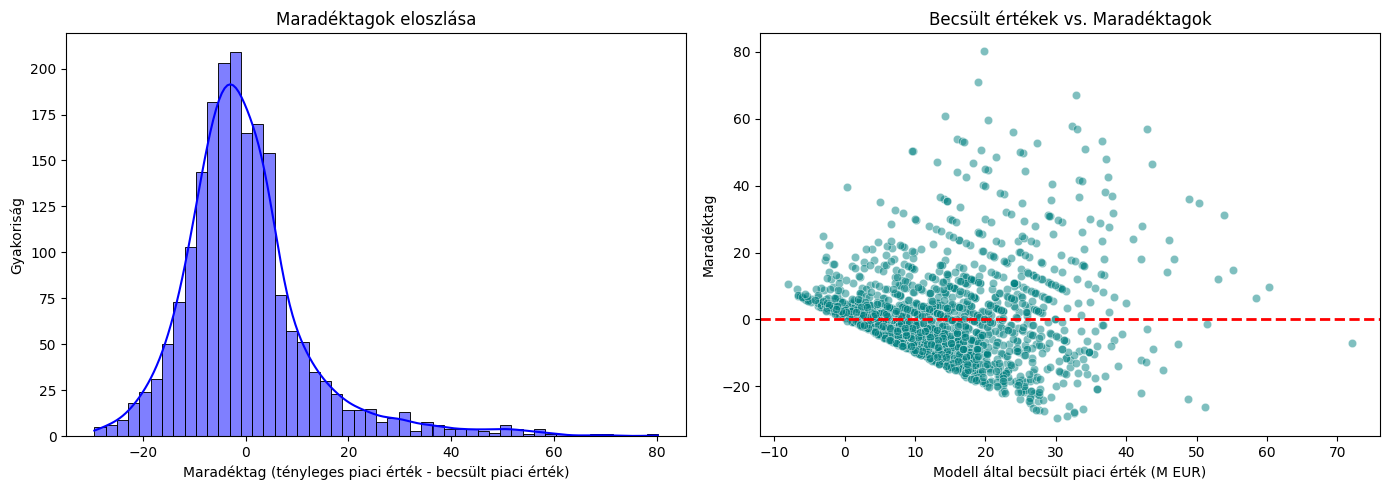

In [72]:
print("- Normalitás: A maradéktagok megközelítőleg normális eloszlást követnek")
print(" - Homoszkedaszticitás: A hibák egyenletesen szóródnak a 0 körül")

fitted_vals = model.fittedvalues
residuals = model.resid

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#normalitás
sns.histplot(residuals, kde=True, color="blue", bins=50, ax=ax[0])
ax[0].set_title("Maradéktagok eloszlása")
ax[0].set_xlabel("Maradéktag (tényleges piaci érték - becsült piaci érték)")
ax[0].set_ylabel("Gyakoriság")

#homoszkedaszticitás
sns.scatterplot(x=fitted_vals, y=residuals, color="teal", alpha=0.5, ax=ax[1])
ax[1].axhline(0, color="red", linestyle="--", linewidth=2)
ax[1].set_title("Becsült értékek vs. Maradéktagok")
ax[1].set_xlabel("Modell által becsült piaci érték (M EUR)")
ax[1].set_ylabel("Maradéktag")

plt.tight_layout()
plt.show()

In [73]:
print("A feltételek a futballpiac specifikumainak megfelelő torzításokkal teljesülnek:")
print("- Normalitás: A csúcs 0 körül van, de az eloszlás enyhén jobbra ferde.")
print("Ennek az oka a szupersztárok: néhány játékosnál az ár jócskán meghaladja a fundamentális becslést, annak ellenére is, hogy korábban már megpróbáltam kiszűrni az outliereket")
print("- Homoszkedaszticitás: Enyhe tölcsér alakzat látható. Az alsó átlós határvonal pedig a 0 alatti ár lehetetlenségéből fakad.")

A feltételek a futballpiac specifikumainak megfelelő torzításokkal teljesülnek:
- Normalitás: A csúcs 0 körül van, de az eloszlás enyhén jobbra ferde.
Ennek az oka a szupersztárok: néhány játékosnál az ár jócskán meghaladja a fundamentális becslést, annak ellenére is, hogy korábban már megpróbáltam kiszűrni az outliereket
- Homoszkedaszticitás: Enyhe tölcsér alakzat látható. Az alsó átlós határvonal pedig a 0 alatti ár lehetetlenségéből fakad.


In [74]:
print("\n5. Feltétel: A maradékok korrelálatlanok")
print("Értékelés: Mivel nem idősoros, hanem keresztmetszeti regressziónk van, így ez az autokorreláció nem áll fenn, így ez a feltétel is teljesül.")


5. Feltétel: A maradékok korrelálatlanok
Értékelés: Mivel nem idősoros, hanem keresztmetszeti regressziónk van, így ez az autokorreláció nem áll fenn, így ez a feltétel is teljesül.
